# 5.1 – Decision Trees
This notebook explains the theoretical foundations of Decision Trees, including intuitive logic and underlying mathematical principles.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay, classification_report, make_scorer, f1_score

%config InlineBackend.figure_format = 'retina'

In [2]:
data = pd.read_csv('/Users/konansul/Downloads/weather_forecast_data.csv')

In [3]:
data

,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure,Rain
0,23.720338,89.592641,7.335604,50.501694,1032.378759,rain
1,27.879734,46.489704,5.952484,4.990053,992.614190,no rain
2,25.069084,83.072843,1.371992,14.855784,1007.231620,no rain
3,23.622080,74.367758,7.050551,67.255282,982.632013,rain
4,20.591370,96.858822,4.643921,47.676444,980.825142,no rain
...,...,...,...,...,...,...
2495,21.791602,45.270902,11.807192,55.044682,1017.686181,no rain
2496,27.558479,46.481744,10.884915,39.715133,1008.590961,no rain
2497,28.108274,43.817178,2.897128,75.842952,999.119187,no rain
2498,14.789275,57.908105,2.374717,2.378743,1046.501875,no rain


# 1. Exploratory Data Analysis (EDA)

In this notebook, we work with a dataset that contains 2,500 observations and 5 feature columns, forming a $X \in \mathbb{R}^{2500 \times 5}$  feature matrix. Each feature column contains real-valued numerical data, meaning there are no categorical variables.

The target column is labeled `Rain` and has two possible string values: `rain` and `no rain`. Since the target has only two distinct classes, this is a binary classification problem. To prepare the data for modeling, the target values are converted from strings to integers, that is, 0 for `no rain` and 1 for `rain`. This transformation is necessary because most machine learning algorithms operate on numerical inputs. Before building a model, we will also perform basic exploratory data analysis (EDA) to better understand the structure and properties of the dataset.

In [4]:
data['Rain'] = data['Rain'].map({'rain': 1, 'no rain': 0})

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  2500 non-null   float64
 1   Humidity     2500 non-null   float64
 2   Wind_Speed   2500 non-null   float64
 3   Cloud_Cover  2500 non-null   float64
 4   Pressure     2500 non-null   float64
 5   Rain         2500 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 117.3 KB


In [6]:
data['Rain'].value_counts()

Rain
0    2186
1     314
Name: count, dtype: int64

In our dataset, the target variable is highly imbalanced 2186 samples correspond to class `no rain`, only 314 samples correspond to class `rain`. This means the dataset contains a strong majority class and a relatively rare minority class. As a result, a model could achieve high accuracy by simply predicting “no rain” all the time but that would not be useful. To address this, we will use the `class_weight` parameter when creating our decision tree model. This will help the model assign higher importance to the minority class and reduce bias toward the majority class.

<Axes: >

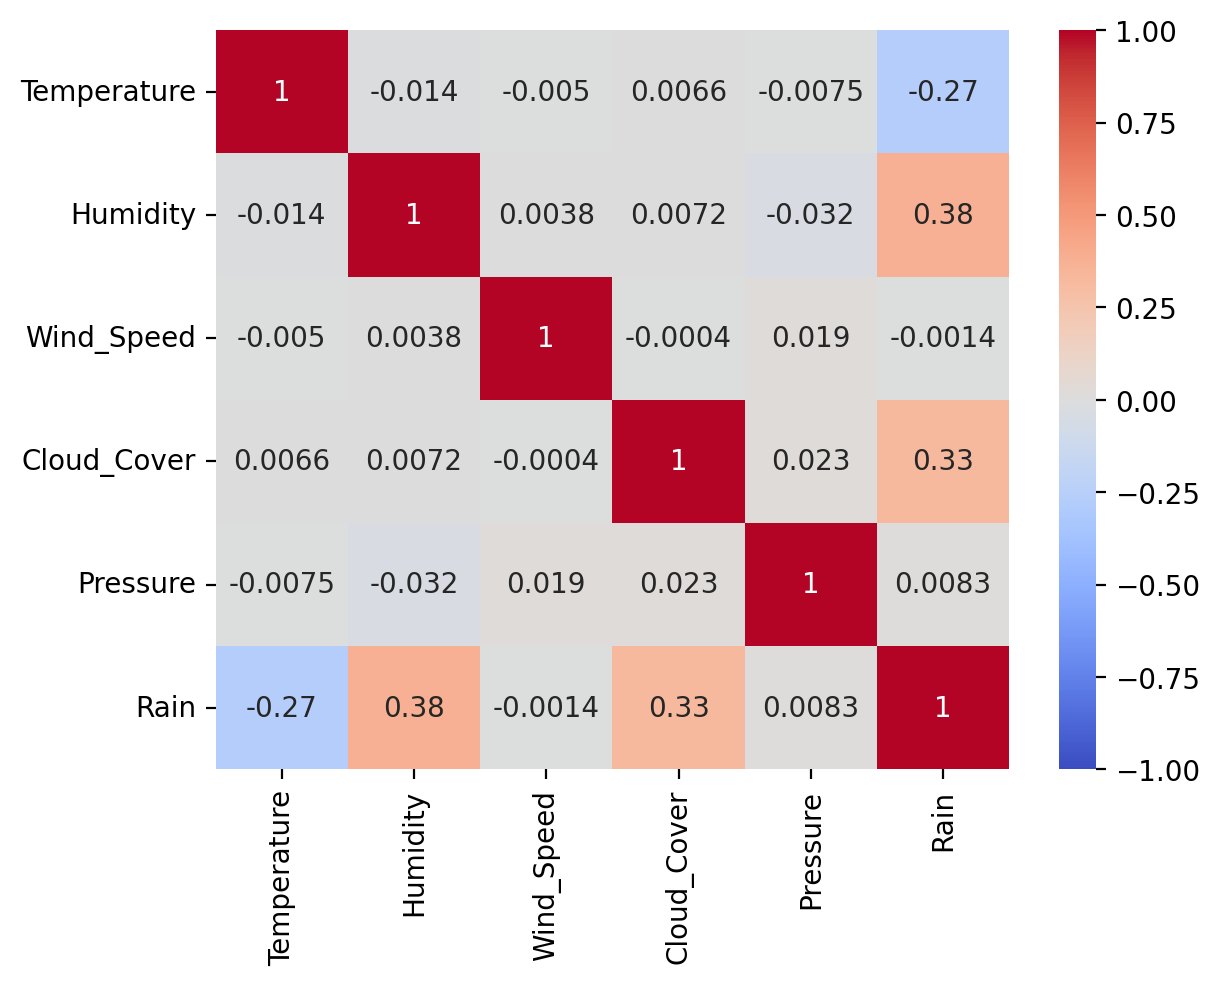

In [7]:
sns.heatmap(data.corr(), annot = True, cmap = 'coolwarm', vmin = -1, vmax = 1)

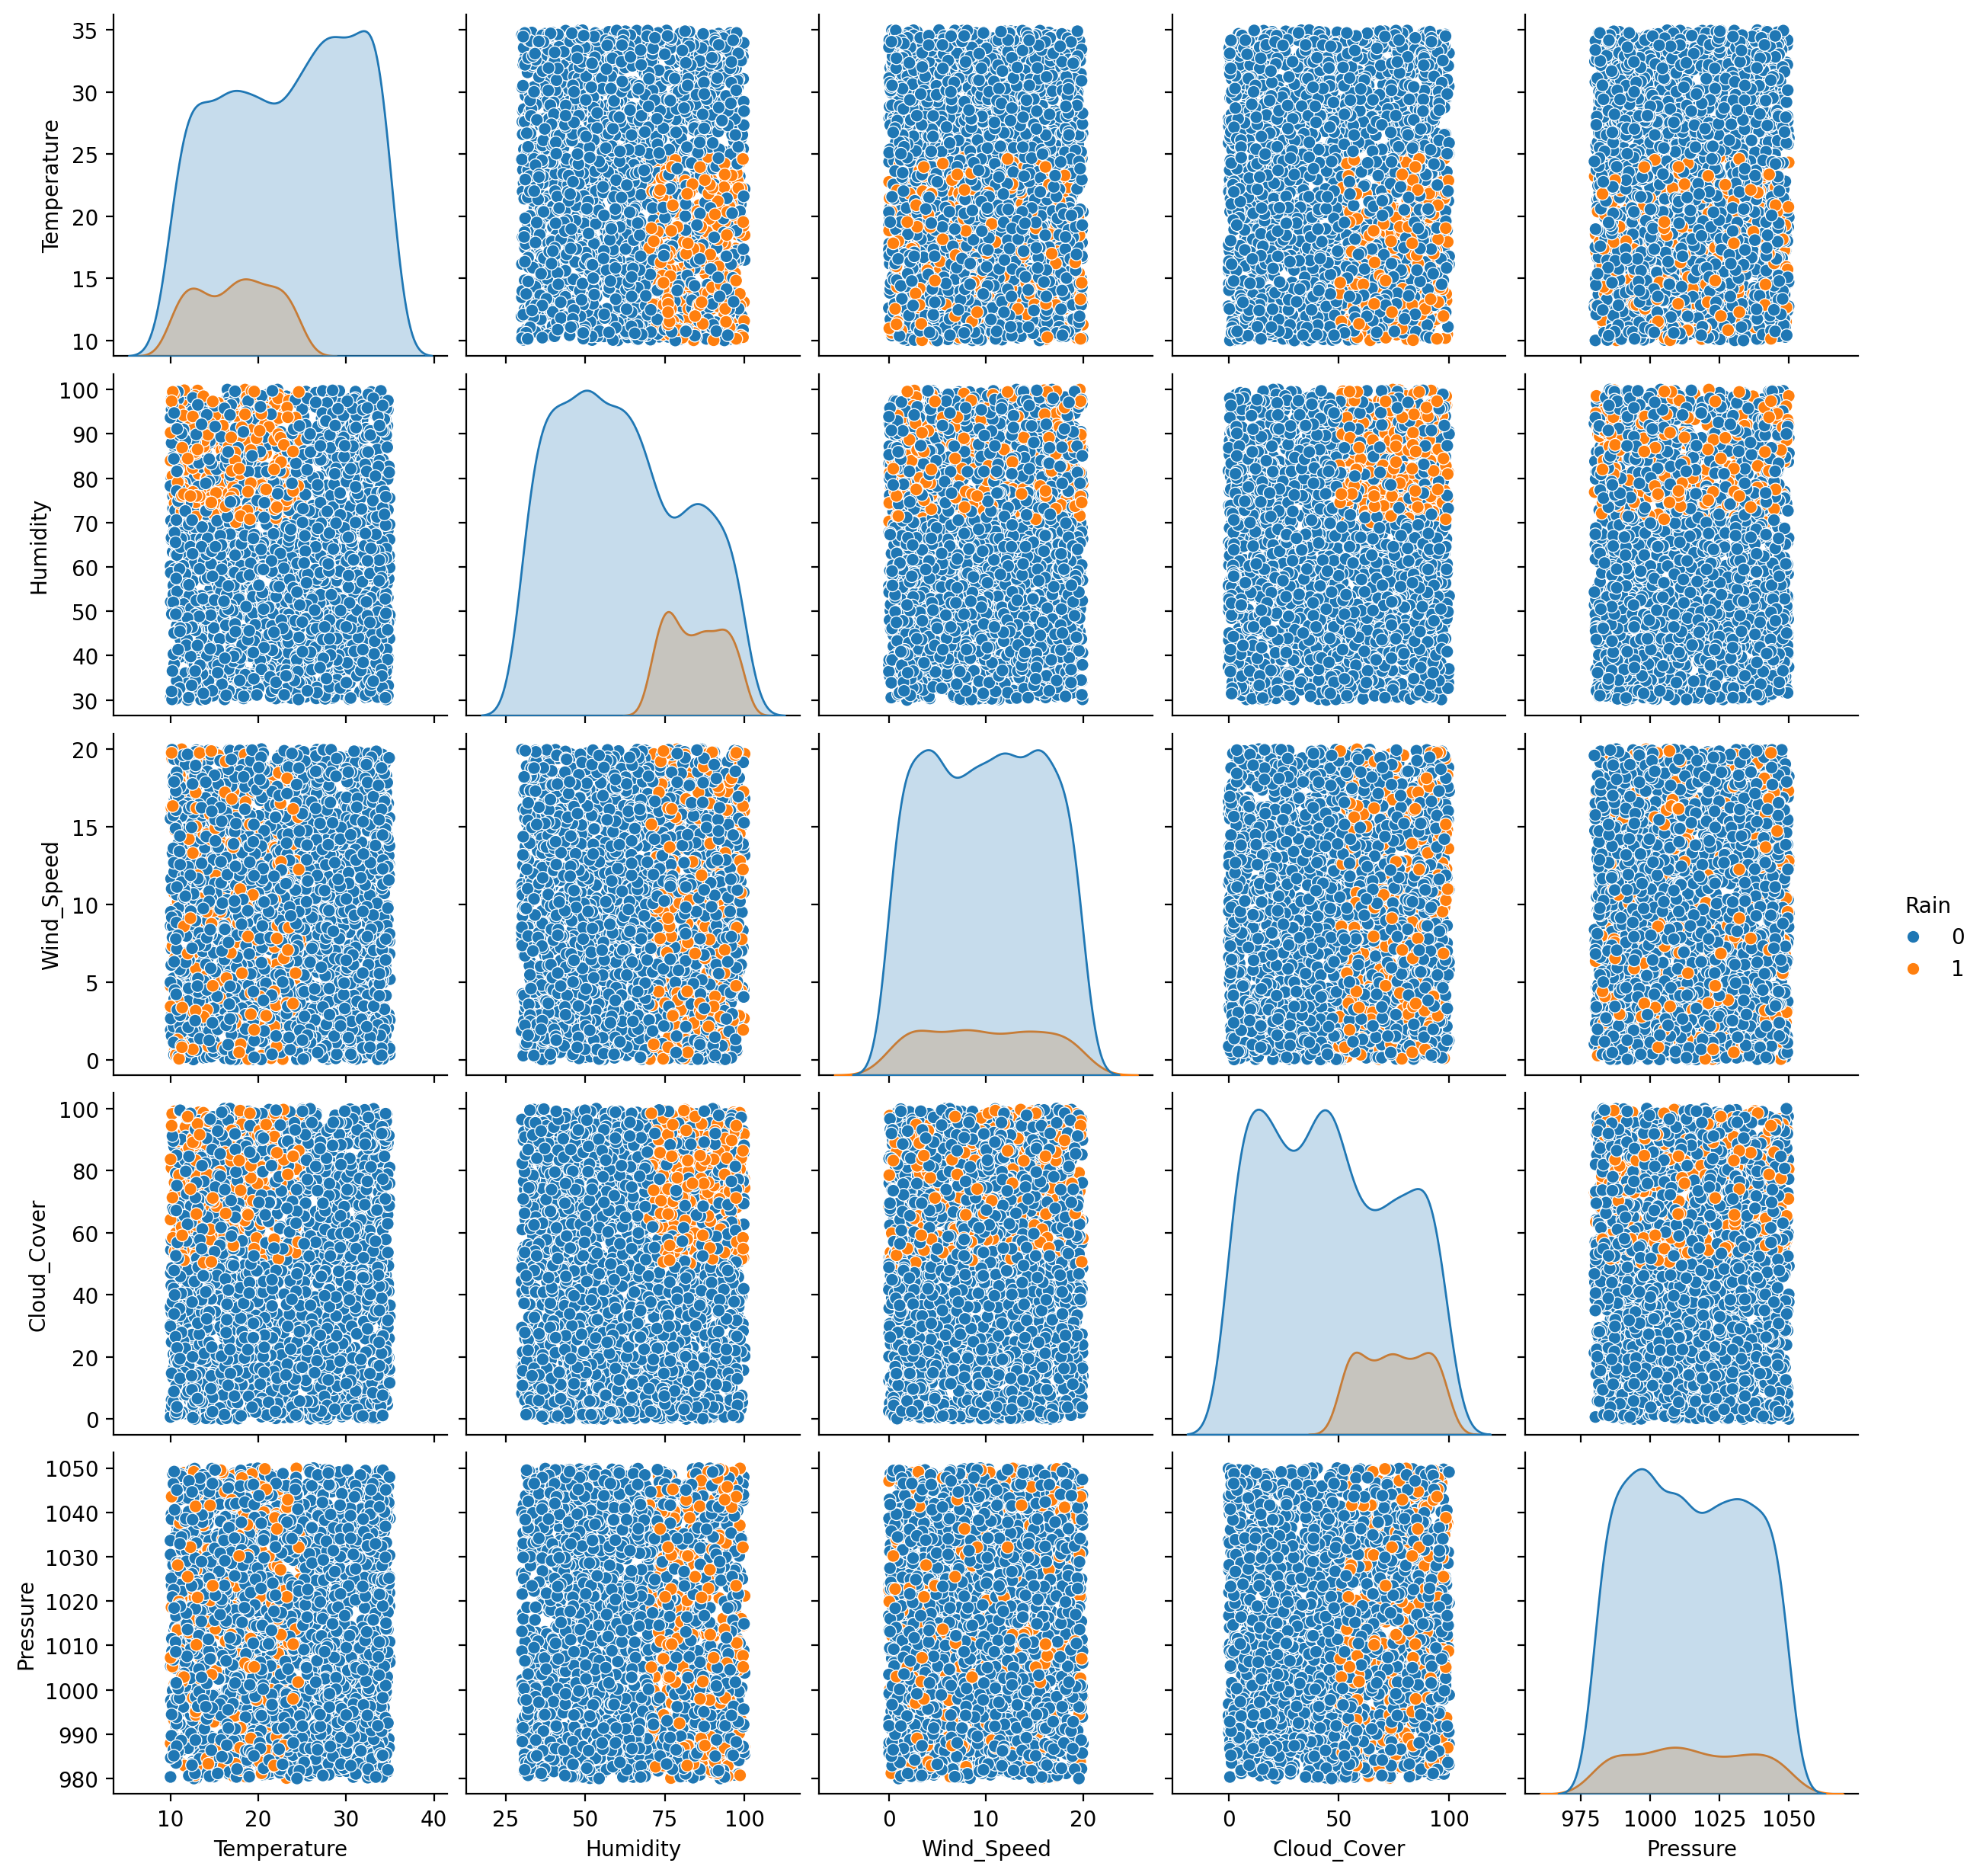

In [8]:
sns.pairplot(data, hue = 'Rain')

# 2. Gini Impurity

**Decision Tree** – a supervised learning model used for classification and regression tasks. It builds a tree-like structure where each internal node represents a decision based on a feature, each branch represents the outcome of that decision, and each leaf node contains a final prediction. At each node, the decision tree searches for the best feature and threshold to split the data. The goal is to divide the dataset into two child nodes such that the purity of the target variable in each child node is maximized. There are several metrics to measure impurity or information gain. The two most commonly used in classification trees are Gini Impurity and Cross-Entropy.

**Gini impurity** – is a metric that measures how impure a node is. It represents the probability that a randomly chosen sample from a node would be incorrectly classified if it were labeled randomly according to the class distribution in that node.

$$ Gini(S) = 1 - \sum_{k=1}^{K} p_k^2 $$
	
where, $K$ is the number of classes,  $p_k$ is the proportion of samples of class k in the node. 
When 
- $Gini = 0$: perfectly pure node (all samples belong to the same class)
- $Gini \approx 0.5$: mixed class distribution (e.g., 50/50 in binary classification)
- $Gini \rightarrow \text{max}$: high impurity, class distribution is uniform

At each step, the algorithm evaluates all possible splits across all features and thresholds, calculates the impurity of each potential split, and selects the one that minimizes impurity (or maximizes gain). This greedy approach is repeated recursively to build the tree.

In [9]:
X = data.drop('Rain', axis = 1)

In [10]:
y = data['Rain']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25)

When initializing the DecisionTreeClassifier, we will address the class imbalance by setting the parameter: `class_weight = 'balanced'`
This automatically adjusts the weights inversely proportional to class frequencies, ensuring the minority class (rain) is not ignored during training.

I have also set the parameter `criterion = 'gini'`, however by default, the decision tree usesgGini impurity as the splitting criterion, so we do not need to explicitly set it. Later in the notebook, we will change the splitting criterion to entropy and compare the performance of both approaches.

In [12]:
model_gini = DecisionTreeClassifier(class_weight = 'balanced', criterion = 'gini')

In [13]:
model_gini.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [14]:
y_pred = model_gini.predict(X_test)

In [15]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       553
           1       1.00      1.00      1.00        72

    accuracy                           1.00       625
   macro avg       1.00      1.00      1.00       625
weighted avg       1.00      1.00      1.00       625



In [16]:
def plot_metrics(model, x_test, y_test):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    ConfusionMatrixDisplay.from_estimator(model, x_test, y_test, ax=axes[0], cmap = 'Blues')
    RocCurveDisplay.from_estimator(model, x_test, y_test, ax=axes[1])
    PrecisionRecallDisplay.from_estimator(model, x_test, y_test, ax=axes[2])
    axes[0].set_title("Confusion Matrix")
    axes[1].set_title("ROC Curve")
    axes[2].set_title("Precision-Recall Curve")
    plt.tight_layout()
    plt.show()

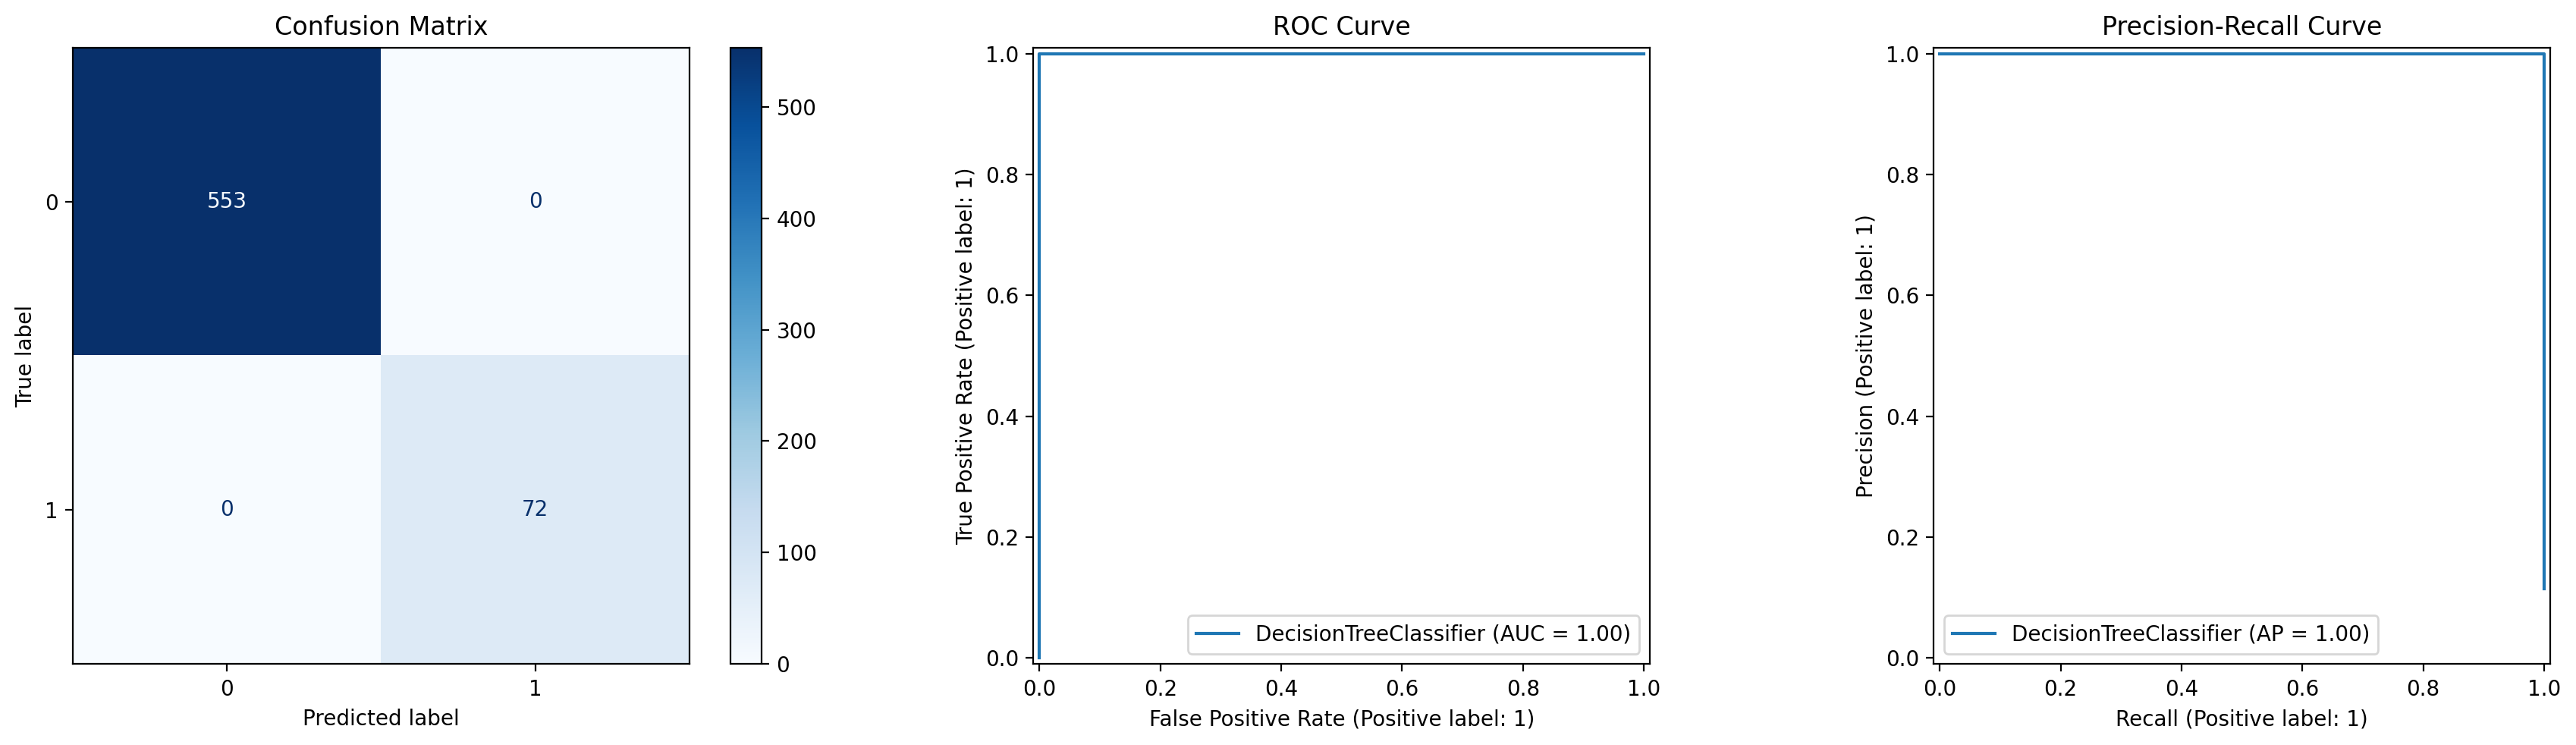

In [17]:
plot_metrics(model_gini, X_test, y_test)

We can visualize the internal structure of the tree using the plot_tree() function from sklearn.tree. This allows us to inspect how the splits are made at each node, observe the Gini impurity values throughout the tree, see the number of samples at each node and understand how the classes are distributed in each leaf. This visualization is extremely helpful for interpreting how the decision tree makes its predictions.

# 3. Plotting the Tree

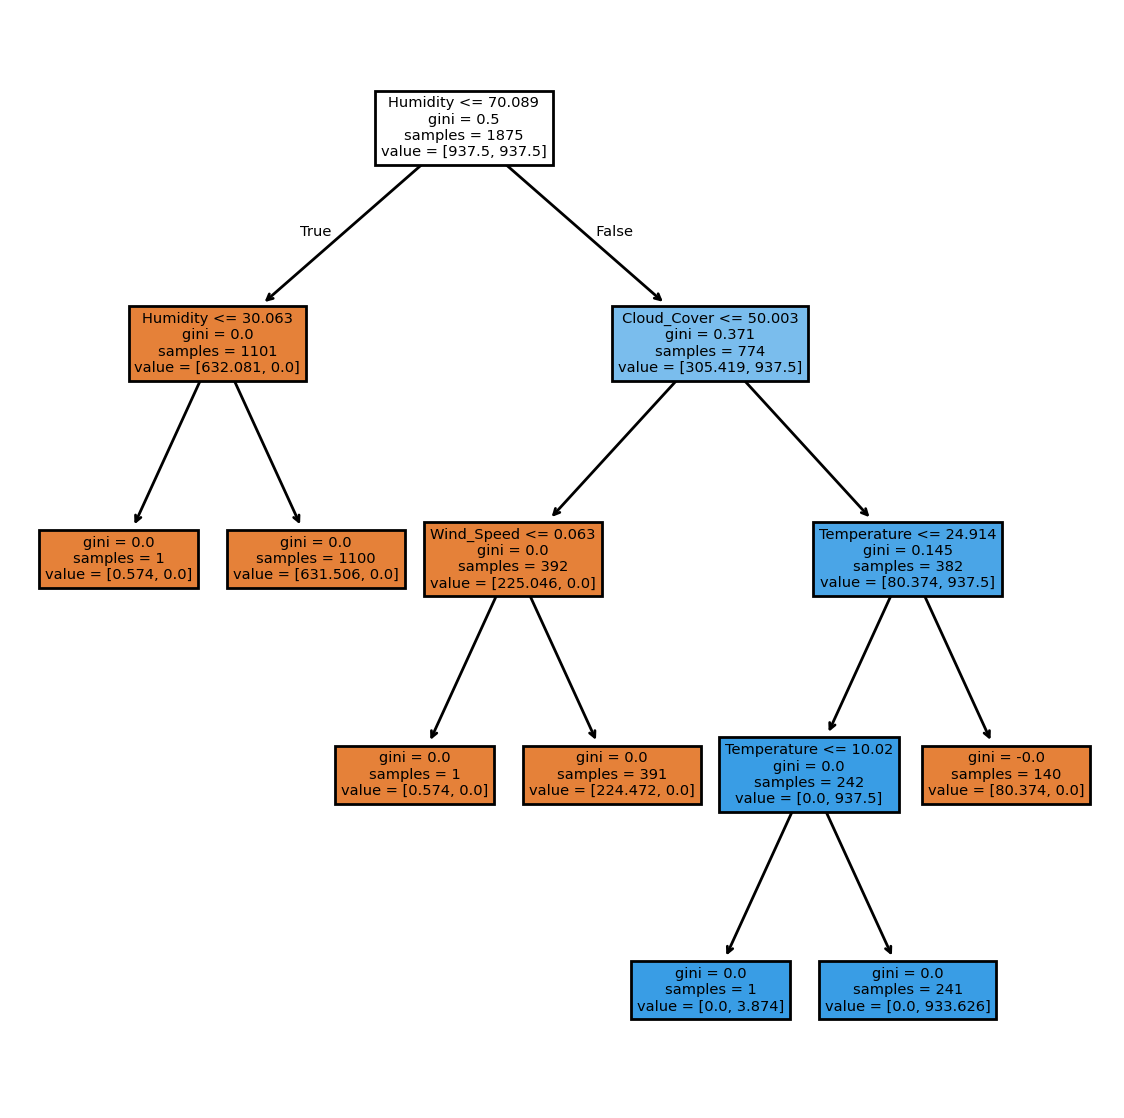

In [18]:
plt.figure(figsize = (7, 7))
plot_tree(model_gini, feature_names = X_train.columns, filled = True);
plt.show()

As we can see, our model performs very well it perfectly predicts all samples in the dataset. However, this may indicate overfitting, especially when the training accuracy reaches 100%. A model that memorizes the training data may fail to generalize well to unseen data. To address this concern, we will repeat the training process using cross-validation, which allows us to better estimate the model’s performance on new data.  As evaluation metric, I choose the F1 score, since it provides a balanced measure of precision and recall, especially important for our imbalanced dataset. Other metrics like accuracy or precision can also be used, but in my opinion the F1 score is more informative in this context. I will perform 10-fold cross-validation to evaluate the model’s generalization ability across different subsets of the data.

In [19]:
f1 = make_scorer(f1_score)

In [20]:
scores = cross_val_score(model_gini, X, y, cv = 10, scoring=f1)

In [21]:
print("F1 scores for each fold:", scores)

F1 scores for each fold: [1.         1.         1.         1.         1.         1.
 1.         0.98360656 1.         1.        ]


In [22]:
print("Average F1 score:", np.mean(scores))

Average F1 score: 0.9983606557377049


As you can see, the average F1 score is 0.9983606, which indicates that our model performs exceptionally well on this dataset. Now, let’s explore another splitting criterion used in decision trees called cross-entropy, or sometimes referred to as information gain.

# 4. Cross-Entropy 

**Cross-entropy** – measures the impurity of a node, similar to Gini impurity, but based on information theory. It is defined as:

$$ H(p) = - \sum_{i=1}^{C} p_i \log_2 p_i $$

where, $ p_i $ is the proportion of class i at a node and $ K $ is the number of classes. In binary classification, where class probabilities are p and 1 - p, the formula becomes:

$$ H(p) = -p \log_2 p - (1 - p) \log_2 (1 - p) $$

The lower the cross-entropy, the purer the node. Like Gini, the decision tree algorithm tries to minimize this value when splitting nodes.

In [23]:
model_entropy = DecisionTreeClassifier(class_weight = 'balanced', criterion = 'entropy')

In [24]:
model_entropy.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [25]:
y_entropy = model_entropy.predict(X_test)

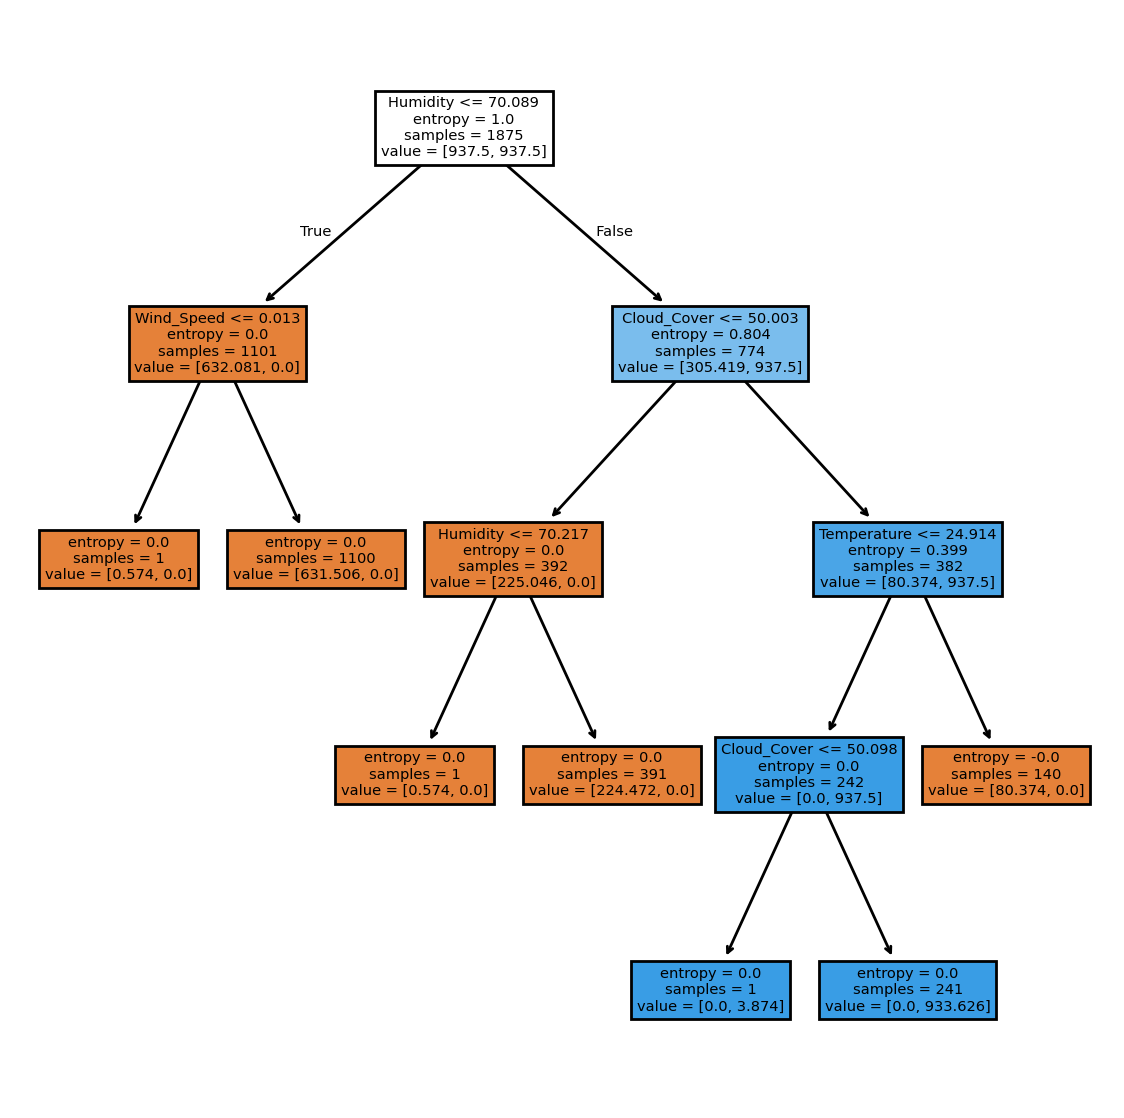

In [26]:
plt.figure(figsize = (7, 7))
plot_tree(model_entropy, feature_names = X_train.columns, filled = True);
plt.show()

In [27]:
print(classification_report(y_test, y_entropy))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       553
           1       1.00      1.00      1.00        72

    accuracy                           1.00       625
   macro avg       1.00      1.00      1.00       625
weighted avg       1.00      1.00      1.00       625



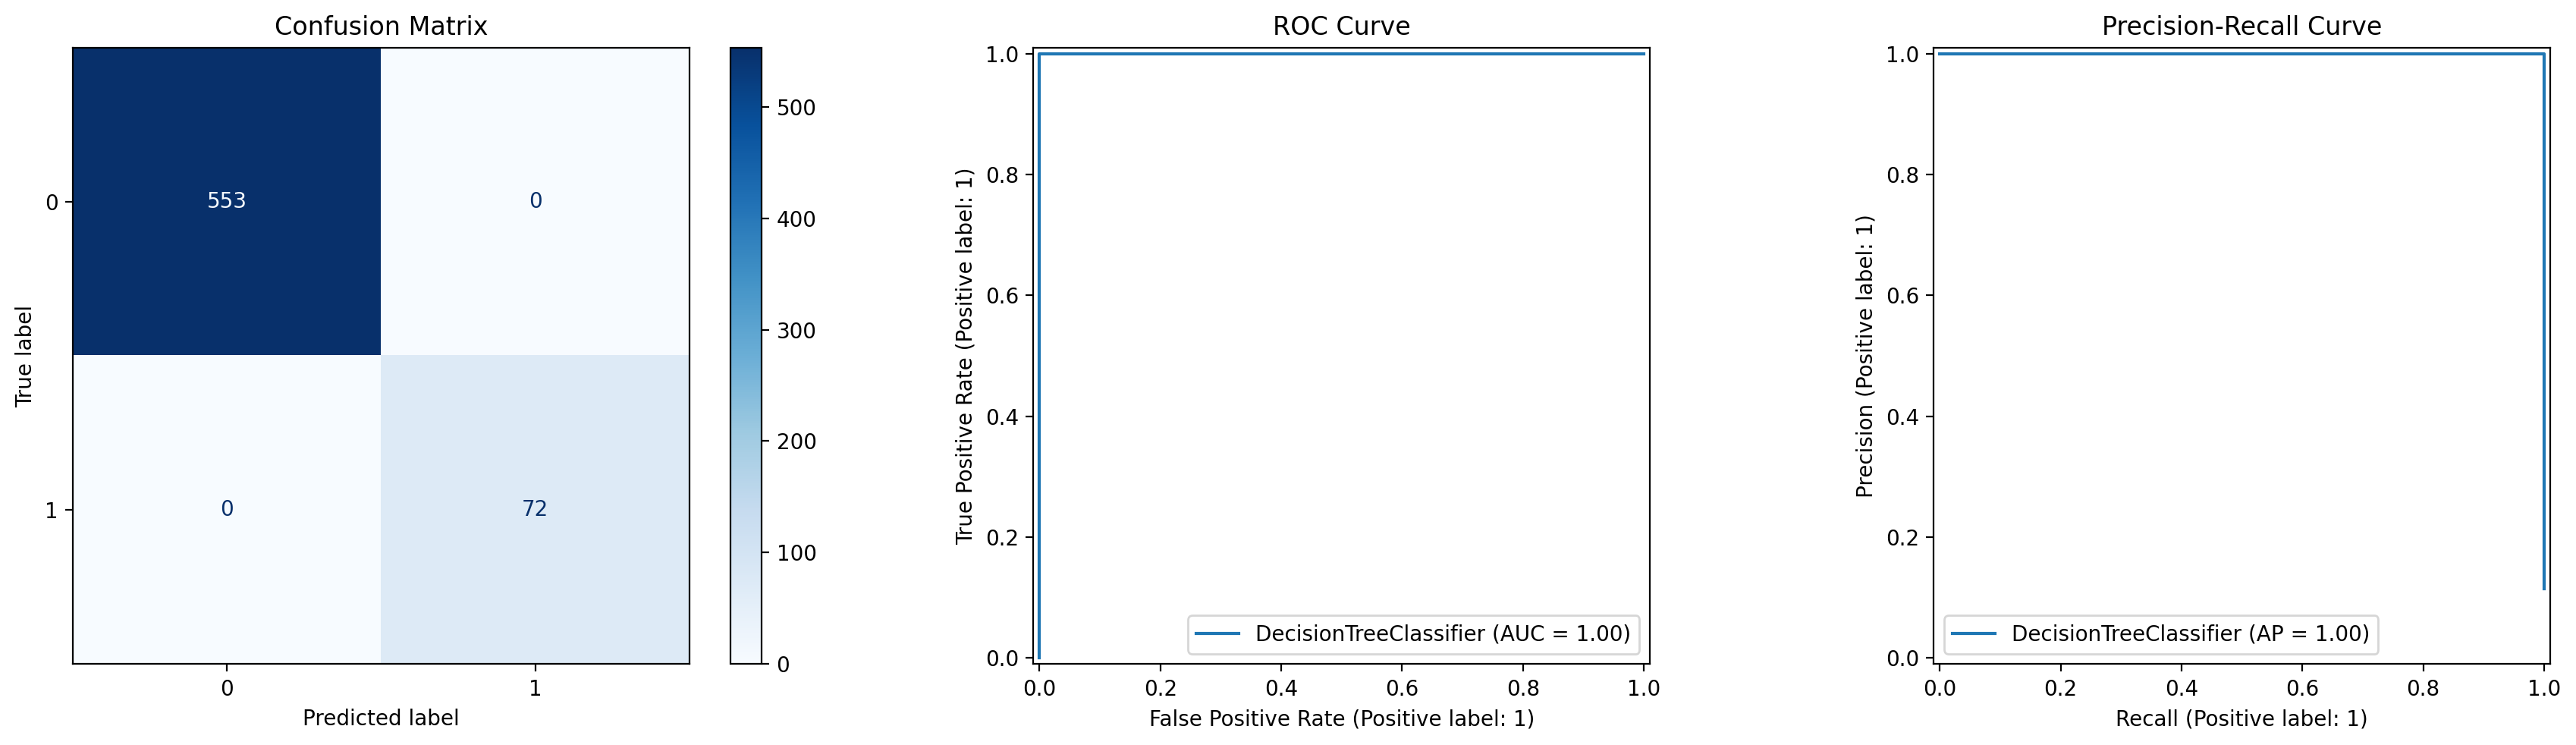

In [28]:
plot_metrics(model_entropy, X_test, y_test)

As we see the model for `criterion = 'entropy'` also works perfect. But here arises the question when to choose Gini or Entropy in Decision Trees? Both Gini impurity and cross-entropy  are measures of impurity used to decide how to split nodes in a decision tree. They often lead to very similar trees and performance, so in most real-world applications, the choice does not matter much. The difference in accuracy is usually negligible, especially with balanced data and clean features.

# 5. References 
**[1]** https://www.geeksforgeeks.org/deep-learning/deep-learning-tutorial/

**[2]** https://www.kaggle.com/datasets/zeeshier/weather-forecast-dataset/data